<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week5/Week_5_Assignment_Nikolai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resampling Methods with the Iris Dataset
## **Nikolai Navarro**
---

In this assignment, we will explore bootstrap resampling, jackknife resampling, and permutation tests using the Iris dataset.

The Iris dataset contains measurements of iris flowers from three species:

- *Setosa*
- *Versicolor*
- *Virginica*

Each flower has four measurements:

- sepal length
- sepal width
- petal length
- petal width

---

## Load the Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Tasks

1.  Print the **number of observations** in the dataset.
2.  Print the **column names**.
3.  Count how many observations exist for each **species**.


In [2]:
print(len(iris))
print(iris.columns)
print(iris["species"].value_counts())

150
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---

## Part 1 - Bootstrap Resampling

We will estimate the **mean sepal length** using bootstrap resampling.


## Task 1 - Basic Statistics

Compute the following statistics for **sepal length**:

-   mean
-   median
-   standard deviation

In [3]:
mean_sepal_length = iris["sepal_length"].mean()
median_sepal_length = iris["sepal_length"].median()
sd_sepal_length = iris["sepal_length"].std()

print(f"mean sepal length: {mean_sepal_length:.3}")
print(f"median sepal length: {median_sepal_length:.3}")
print(f"standard deviation sepal length: {sd_sepal_length:.3}")

mean sepal length: 5.84
median sepal length: 5.8
standard deviation sepal length: 0.828


## Task 2 --- Bootstrap the Mean

Perform **5,000 bootstrap resamples**.

Procedure:

1.  Sample the dataset **with replacement**.
2.  Each sample must contain **150 observations**.
3.  Compute the **mean sepal length** for each resample.
4.  Store the results.

Plot the **distribution of bootstrap means**.

Text(0.5, 0, 'Mean Sepal Length')

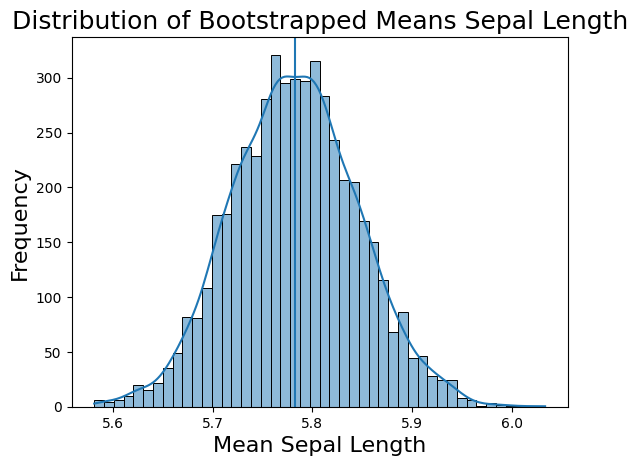

In [4]:
n_bootstrap = 5000
sample_n = 150
sample = np.random.choice(iris["sepal_length"], size=sample_n, replace=True)
bootstrap_means = []

for b in range(n_bootstrap):
  bootstrap_means.append(np.mean(np.random.choice(sample, size=sample_n, replace=True)))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Means Sepal Length', fontsize=18)
plt.ylabel('Frequency', fontsize=16)
plt.xlabel('Mean Sepal Length', fontsize=16)

## Task 3 --- Confidence Interval

Using the bootstrap results, compute the **95% confidence interval**
using the percentile method:

CI = \[2.5%, 97.5%\]

Report:

-   Bootstrap mean
-   Lower bound
-   Upper bound

In [5]:
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

Bootstrapped Mean: 5.78
95% Confidence Intervals: [5.66, 5.91]


### Question

Why is it mathematically necessary to sample **with replacement** in
bootstrap resampling?

By sampling with replacement it allows data to be selected multiple times giving each piece of data the same chance of being chosen simulating variablity in the population. Without replacement the data would only be selected once effecting the possibility of other data being chosen as well as not being able to simulate variability.

---

## Part 2 --- Jackknife Resampling

## Task 4 --- Jackknife the Mean

Create jackknife samples by removing **one observation at a time**.

Steps:

1.  For each observation i, remove it from the dataset.
2.  Compute the mean of the remaining observations.
3.  Store the result.

Plot the **distribution of jackknife means**.

In [30]:
def jackknife_resampling(sample):
    n = sample_n
    jackknife_means = np.zeros(n)

    for i in range(n):
        jackknife_sample = np.delete(sample, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    jackknife_mean = np.mean(jackknife_means)

    original_mean = np.mean(sample)
    bias = (n - 1)*(original_mean - jackknife_mean)

    variance = (n - 1) * np.mean((jackknife_means - jackknife_mean) ** 2)

    return jackknife_mean, bias, variance, jackknife_means

mean, bias, variance, jackknife_means = jackknife_resampling(sample)
print(f"Jackknife Mean: {mean}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

Jackknife Mean: 5.783333333333333
Bias: 0.0
Variance: 0.004004847129008231


Text(0, 0.5, 'Frequency')

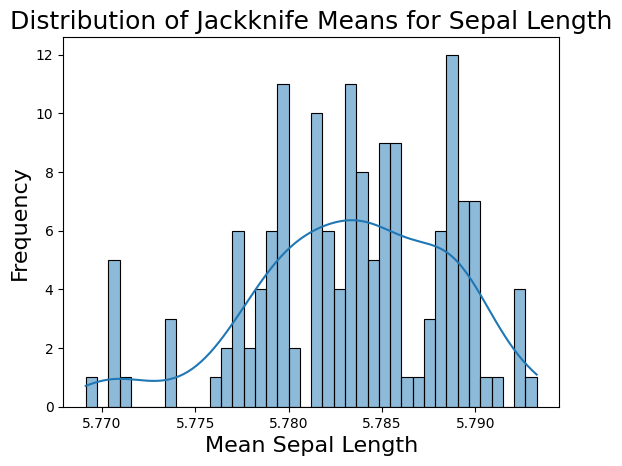

In [40]:
sns.histplot(jackknife_means, kde=True, bins=40)
plt.title("Distribution of Jackknife Means for Sepal Length", fontsize=18)
plt.xlabel("Mean Sepal Length", fontsize=16)
plt.ylabel("Frequency", fontsize=16)

### Question

If the dataset contains n observations, **exactly how many jackknife
samples** are created?

n samples will be created. In this case 150 samples were created.


---

## Part 3 --- Permutation Test

We will test whether **sepal length differs significantly between two
species**.

For this task, use:

-   **Versicolor**
-   **Virginica**

## Task 5 --- Observed Statistic

Compute the observed difference in means:

difference = mean(Versicolor) - mean(Virginica)

In [41]:
versicolor_lengths = iris[iris["species"] == "versicolor"]["sepal_length"]
virginica_lengths = iris[iris["species"] == "virginica"]["sepal_length"]

difference = np.mean(versicolor_lengths) - np.mean(virginica_lengths)
print(f"Observed Difference: {difference:.3}")

Observed Difference: -0.652


## Task 6 --- Permutation Simulation

Run **1,000 permutations**.

Procedure:

1.  Combine the two species into one dataset.
2.  **Shuffle (permute) the labels**.
3.  Split the data back into two groups of the original sizes.
4.  Compute the difference in means.
5.  Store the result.

Plot the **permutation distribution**.

-0.22419999999999937 0.2319999999999994


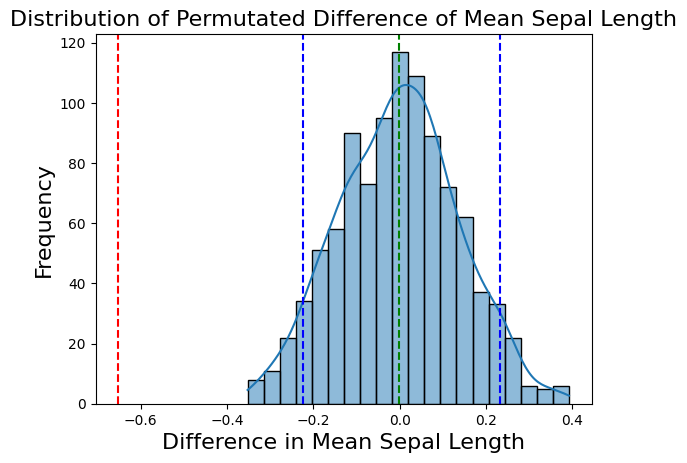

In [60]:
from numpy.random.mtrand import permutation
combine_species= np.concatenate((versicolor_lengths, virginica_lengths))
n_versicolor = len(versicolor_lengths)
n_virginica = len(virginica_lengths)

simu_diff = []
permutation = 1000
for i in range(permutation):
  perm_sample = np.random.permutation(combine_species)

  perm_versicolor = perm_sample[:n_versicolor]
  perm_virginica = perm_sample[n_versicolor:]

  perm_diff = np.mean(perm_versicolor) - np.mean(perm_virginica)
  simu_diff.append(perm_diff)

upper = np.quantile(simu_diff, 0.95)
lower = np.quantile(simu_diff, 0.05)
print(lower, upper)

sns.histplot(simu_diff, kde=True)
plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color="green", linestyle="--")
plt.axvline(x=difference, ymin=0, ymax=1, color="red", linestyle="--")
plt.title("Distribution of Permutated Difference of Mean Sepal Length", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.xlabel("Difference in Mean Sepal Length", fontsize=16)
plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--')


## Task 7 --- p-value

Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total
simulations)

Interpret the result at α = 0.05.

In [62]:
p_value = np.sum(np.abs(simu_diff) >= np.abs(difference)) / 1000
print(f'p-value: {p_value:.3f}')

p-value: 0.000


## Questions

1.  What is the **null hypothesis (H0)** in this specific test?

The null hypothesis is that there is no difference between the mean sepal lengths of the versicolor and virginica species.

2.  What does the **permutation distribution** represent in terms of
    **random chance**?

The permutation distribution shows the distribution of the difference in the mean sepal lengths between the species if it were to occur randomly. In this case the distribution doesn't allign with the observed difference show by the red line.
    
3.  Based on your p-value, do you **reject** or **fail to reject** the
    null hypothesis?

Because the p-value of 0 is less than 0.05 we have enough evidence to reject the null meaning there is a significant difference between the mean sepal lengths of the versicolor and virginica species.